# Env setup

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import ParameterGrid

import joblib
import sys 
sys.path.append('../../')

import src.fda.kde.estimators           as kde 
import src.fda.plots                    as fplt
import src.fda.utils                    as futils
import src.forecasting.risk             as risk
import src.forecasting.cross_validation as crossVal
import src.forecasting.pipelines        as fp

from tqdm.auto import tqdm

In [12]:
# Data
data_path = "../../data/processed/"
returns_path = ''.join([data_path, 'ibovespa_treated.xlsx'])
df_returns = pd.read_excel(returns_path, index_col="time")
df_returns

,2024-12-02,2024-12-03,2024-12-04,2024-12-05,2024-12-06,2024-12-09,2024-12-10,2024-12-11,2024-12-12,2024-12-13,...,2025-11-14,2025-11-17,2025-11-18,2025-11-19,2025-11-21,2025-11-24,2025-11-25,2025-11-26,2025-11-27,2025-11-28
time,,,,,,,,,,,,,,,,,,,,,
10:05:00,-0.002271,0.003372,0.001716,0.005538,0.000069,0.006429,0.002343,0.001918,-0.007582,-0.000413,...,-0.001522,0.000739,-0.000613,0.000306,-0.002021,-0.000810,0.001557,-0.001565,-0.000193,0.002906
10:10:00,-0.000582,0.002832,-0.000502,0.000739,0.000261,0.001891,0.000775,-0.001172,0.000216,-0.000432,...,0.000360,-0.000105,-0.000159,-0.000362,0.000092,0.001131,0.001170,0.000202,0.000556,0.000475
10:15:00,-0.001997,0.001091,0.000111,-0.000192,0.000407,-0.001392,-0.000477,-0.001526,0.000198,-0.001821,...,0.001121,-0.000284,0.003272,-0.001107,-0.001012,-0.000174,0.001002,0.001815,-0.000168,0.000973
10:20:00,-0.000037,-0.000505,-0.000327,-0.000580,-0.000436,-0.000405,0.001263,0.000676,-0.002667,0.001033,...,0.000449,0.000335,0.000853,0.000981,-0.000057,-0.000096,0.000832,0.001951,0.001060,-0.001004
10:25:00,0.000364,-0.001532,0.000429,-0.000426,-0.000162,-0.000130,0.000060,0.000818,-0.000970,0.000670,...,-0.000871,-0.000559,0.001030,-0.000749,-0.001194,0.001338,0.000128,0.001279,-0.000162,-0.000651
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16:40:00,-0.000169,0.000195,-0.000833,0.000137,0.000127,0.000062,0.000253,-0.003736,0.000405,0.000168,...,-0.000255,-0.000412,-0.000398,-0.000301,-0.000428,-0.000232,0.000473,-0.000521,0.000118,-0.000099
16:45:00,-0.000246,-0.000226,-0.000897,0.000536,0.001010,0.000047,-0.000063,0.002746,-0.000154,-0.000783,...,0.000344,0.000610,0.000224,-0.000353,0.000034,0.000054,-0.000519,0.000386,-0.000085,-0.000468
16:50:00,-0.000512,-0.000546,0.000553,0.000278,-0.000393,-0.000625,0.000141,-0.002952,0.002424,0.000244,...,0.000202,-0.000350,-0.000240,0.000239,-0.000314,-0.000175,0.000022,0.000298,0.000399,-0.000041


## Realized volatility

<Axes: title={'center': 'log(RV)'}, xlabel='date'>

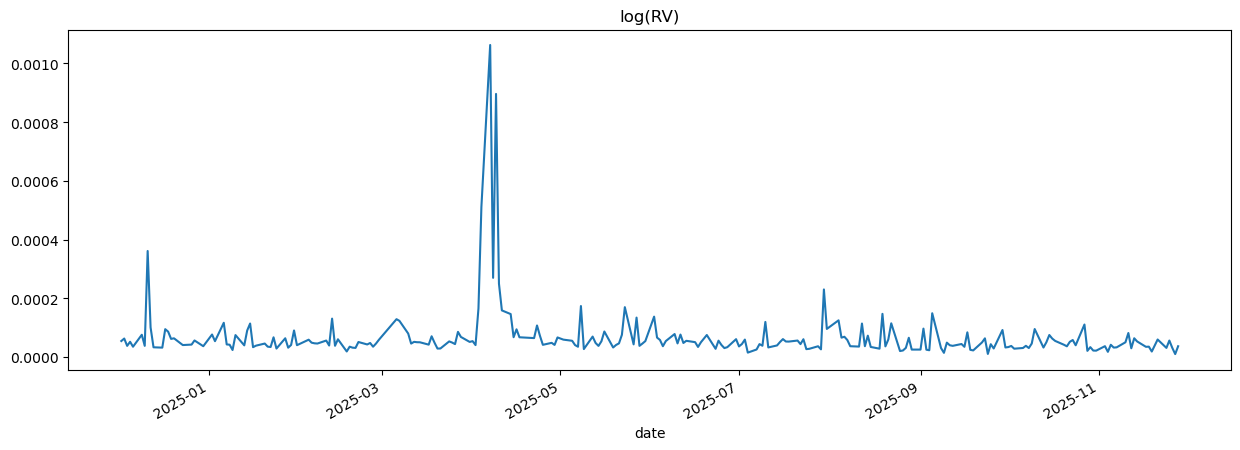

In [4]:
LOG_VOLATILITY:bool = False # if false, doesn't apply log to realized volatility.
DHAT = 5 # number of the dimensions from dFPC to keep and work with
df_squared_returns = df**2
realized_volatility = df_squared_returns.sum(axis=0)
if LOG_VOLATILITY:
    realized_volatility = np.log(realized_volatility)
realized_volatility.name = "realized_volatility"
realized_volatility.index.name = "date"
realized_volatility.plot(title="log(RV)", figsize=(15,5))

In [11]:
t_dfs = range(3,6)


rot_grid = {
    "method": ["rot"],
    "kernel": ["gaussian", "epanechnikov"],
    "sigma_robust": [True, False]
}

lcv_sklearn_grid = {
    "method": ["cross_validate"],
    "kernel": ["gaussian"], 
    "cv": ["LOO"]#[5]
}

adaptive_grid = {
    "method": ["adaptive"], 
    "kernel": ["gaussian", "epanechnikov"]
}

lcv_t_grid = {
    "method": ["cross_validate"],
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
    "cv": ["LOO"]
}

adaptive_grid_t = {
    "method": ["adaptive"], 
    "kernel": ["t-student"],
    "df": [df for df in t_dfs],
}


density_param_grid = {}
for grid in [rot_grid, lcv_sklearn_grid, lcv_t_grid, adaptive_grid, adaptive_grid_t]:
    for params in ParameterGrid(grid):
        
        key_parts = [params["kernel"]]
        if "method" in params: key_parts.append(params["method"])
        if "df" in params: key_parts.append(f"df={params['df']}")
        if params.get("sigma_robust"): key_parts.append("robust")
        if params.get("cv") == "LOO": key_parts.append("loo")
        
        full_model_name = "_".join(key_parts).replace(".", "")
        
        kernel_label = params["kernel"]
        if "df" in params:
            kernel_label += f"+df={params['df']}"
            
        bw_label = params.get("method", "fixed")
        if params.get("sigma_robust"): bw_label += "_robust"
        if params.get("cv") == "LOO": bw_label += "_loo"


        density_param_grid[full_model_name] = {
            "kernel": kernel_label,
            "bandwidth": bw_label,
            "params": params  
        }

print("KDE models:")
for name, values in density_param_grid.items():
    print("\t",name, ":", values["params"])

print(f"Total KDE models: {len(density_param_grid.items())}")

KDE models:
	 gaussian_rot_robust : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': True}
	 gaussian_rot : {'kernel': 'gaussian', 'method': 'rot', 'sigma_robust': False}
	 epanechnikov_rot_robust : {'kernel': 'epanechnikov', 'method': 'rot', 'sigma_robust': True}
	 epanechnikov_rot : {'kernel': 'epanechnikov', 'method': 'rot', 'sigma_robust': False}
	 gaussian_cross_validate_loo : {'cv': 'LOO', 'kernel': 'gaussian', 'method': 'cross_validate'}
	 t-student_cross_validate_df=3_loo : {'cv': 'LOO', 'df': 3, 'kernel': 't-student', 'method': 'cross_validate'}
	 t-student_cross_validate_df=4_loo : {'cv': 'LOO', 'df': 4, 'kernel': 't-student', 'method': 'cross_validate'}
	 t-student_cross_validate_df=5_loo : {'cv': 'LOO', 'df': 5, 'kernel': 't-student', 'method': 'cross_validate'}
	 gaussian_adaptive : {'kernel': 'gaussian', 'method': 'adaptive'}
	 epanechnikov_adaptive : {'kernel': 'epanechnikov', 'method': 'adaptive'}
	 t-student_adaptive_df=3 : {'df': 3, 'kernel': 't-student', 'meth

In [ ]:
# Density normalization
# 1. Define your sub-grids to avoid invalid combinations
weigh_grids = [
    {
        'mean_mode': [False, 'expanding'], #'full'],
        'window': [None]
    },
    {
        'mean_mode': ['rolling'],
        'window': [5, 21, 63] # week, month, quarter
    }
]

# 2. Build the dictionary with unique keys
weigh_param_grid = {}
for grid in weigh_grids:
    for params in ParameterGrid(grid):
        # Start the key with the mode
        key_parts = [str(params["mean_mode"])]
        
        # Add the window to the key if it exists (for rolling)
        if params["window"] is not None:
            key_parts.append(f"w{params['window']}")
        
        # Create a clean string key: e.g., "rolling_w5" or "expanding"
        name = "_".join(key_parts)
        weigh_param_grid[name] = params

print("Posprocessing models:")
for name, params in weigh_param_grid.items():
    print("\t",name, ":", params)

Posprocessing models:
	 False : {'mean_mode': False, 'window': None}
	 expanding : {'mean_mode': 'expanding', 'window': None}
	 rolling_w5 : {'mean_mode': 'rolling', 'window': 5}
	 rolling_w21 : {'mean_mode': 'rolling', 'window': 21}
	 rolling_w63 : {'mean_mode': 'rolling', 'window': 63}


In [10]:
theta = []

for kde_name, kde_params in density_param_grid.items():
    for post_name, post_params in weigh_param_grid.items():
        theta.append({
            "kde_name": kde_name,
            **kde_params,
            "postprocess_name": post_name,
            **post_params
        })

print("Total KDE configurations:", len(theta))

Total KDE configurations: 65


In [19]:
kde_databases = {}

for name, params in density_param_grid.items():
    print(f"Processing configuration: {name}")

    bw_params  = params["params"]
    
    # bandwidths
    df_h = kde.df_bandwidth_selector(df_returns, **bw_params)    
    kde_params = {k: v for k, v in bw_params.items() if k in ['kernel', 'df']}
    
    # kdes
    df_grids, df_densities = kde.df_to_kde(
        X=df_returns, 
        h=df_h, 
        normalize_densities=False,
        **kde_params
    )

    # postprocessing
    for pp_name, pp_params in weigh_param_grid.items():
        database_name = "___".join([name, pp_name])
        print(f"\t\t{database_name}")
        if pp_name == 'False':
            pass
        else:
            base_grid = np.linspace(df_grids.min().min(), df_grids.max().max(), 5001)
            df_densities = kde.weigh_norm_densities(
                                            df_densities=df_densities,
                                            support=base_grid,
                                            **pp_params
            )


        kde_databases[database_name]= {
            "df_h":         df_h,
            "df_grids":     df_grids,
            "df_densities": df_densities
        }

Processing configuration: gaussian_rot_robust
		gaussian_rot_robust___False
		gaussian_rot_robust___expanding
		gaussian_rot_robust___rolling_w5
		gaussian_rot_robust___rolling_w21
		gaussian_rot_robust___rolling_w63
Processing configuration: gaussian_rot
		gaussian_rot___False
		gaussian_rot___expanding
		gaussian_rot___rolling_w5
		gaussian_rot___rolling_w21
		gaussian_rot___rolling_w63
Processing configuration: epanechnikov_rot_robust
		epanechnikov_rot_robust___False
		epanechnikov_rot_robust___expanding
		epanechnikov_rot_robust___rolling_w5
		epanechnikov_rot_robust___rolling_w21
		epanechnikov_rot_robust___rolling_w63
Processing configuration: epanechnikov_rot
		epanechnikov_rot___False
		epanechnikov_rot___expanding
		epanechnikov_rot___rolling_w5
		epanechnikov_rot___rolling_w21
		epanechnikov_rot___rolling_w63
Processing configuration: gaussian_cross_validate_loo
		gaussian_cross_validate_loo___False
		gaussian_cross_validate_loo___expanding
		gaussian_cross_validate_loo___ro

In [23]:
joblib.dump(kde_databases, "../../data/processed/risk/kdes.jbl")

kde_databases = joblib.load("../../data/processed/risk/kdes.jbl")

In [27]:
kde_databases["gaussian_rot_robust___False"].keys()

dict_keys(['df_h', 'df_grids', 'df_densities'])

## Train test split

In [ ]:
INITIAL_WINDOW = 180

pbar = tqdm(total= df_densities.shape[1] - INITIAL_WINDOW, desc="Total CV Progress")
n_observations = df_squared_returns.shape[0]
rv_results = []

for kde_model_name, data in kde_databases.items():
    # selects specific KDE for database and simulation
    # kde_selection_model = kde_databases[kde_model_name]
    kde_selection_dens  = data["df_densities"]
    kde_selection_supp  = data["df_grids"]
    
    windows = crossVal.expanding_window_cv(df_densities.shape[1], h=1, initial_window=INITIAL_WINDOW)
    for fold, window in enumerate(windows):
        
        # TRAIN-TEST SPLIT FOR DENSITIES AND SUPPORTS
        idx_train = window[0]
        idx_test  = window[1]
        Y_train_support, Y_train = kde_selection_supp.iloc[:,idx_train], kde_selection_dens.iloc[:,idx_train]
        Y_test_support , Y_test =  kde_selection_supp.iloc[:,idx_test],  kde_selection_dens.iloc[:,idx_test]
        rv_train, rv_test = realized_volatility.iloc[idx_train], realized_volatility.iloc[idx_test]

        #----------------------------------
        #----------- ESTIMATION -----------
        #----------------------------------

        #-------- mdFPC----------
        # mdFPC parameters
        m_dFPC_kwargs = {
            "p": 5,
            "dimension": 2
        }
        # initialize class
        forecaster = fp.DensityForecaster(kdfpc_kwargs=m_dFPC_kwargs, maxlags=10)
        # fit model
        forecaster.fit(Y_train, Y_train_support)
        # fitted scores
        fitted_mdfpc_scores = forecaster.model_kdfpc.etahat
        # forecast dict
        mdfpc_fc = forecaster.predict(horizon=1)
        mdfpc_fc_scores = pd.DataFrame(mdfpc_fc["future_scores"].T, columns=forecaster.model_kdfpc.etahat.columns)
        # support forecast
        support_fc = mdfpc_fc["future_supports"]
        # density forecast
        density_fc = mdfpc_fc["future_densities"]
        # equalize col names
        support_fc.columns = density_fc.columns = Y_test.columns
        # align forecast with kde
        df_supp, df_f, df_mdfpc =  futils.align_densities(
                                        Y_test_support, 
                                        Y_test, 
                                        support_fc, 
                                        density_fc, 
                                        Y_test.columns
                                        )
        
        #-------- dFPC----------
        # dFPC parameters
        dFPC_kwargs = {
            "lag_max": 5,
            "alpha": 0.10,
            "B": 1000,
            "p": 5,
            "select_ncomp": False,
            "dimension": 2,
            "u": Y_train_support.iloc[:,0],
            "du": Y_train_support.iloc[:,0][1] - Y_train_support.iloc[:,0][0]
        }
        # initialize
        forecaster = fp.DensityForecaster_HZ(kdfpc_kwargs=dFPC_kwargs, maxlags=10)
        # fit
        forecaster.fit(Y_train, Y_train_support)
        fitted_dfpc_scores = forecaster.model_kdfpc.etahat
        # predict
        results = forecaster.predict(horizon=len(Y_test.columns), forecast_index=Y_test.columns)

        dfpc_fc_scores = pd.DataFrame(results["future_scores"].T, columns=forecaster.model_kdfpc.etahat.columns)
        # Access aligned results
        forecast_densities = results["future_curves"]
        forecast_densities.columns = df_mdfpc.columns

        objects = {
            "mdfpc": {
                "density_forecast": df_mdfpc,
                "scores_fitted":    fitted_mdfpc_scores,
                "scores_forecast":  mdfpc_fc_scores
            },

            "dfpc": {
                "density_forecast": forecast_densities,
                "scores_fitted":    fitted_dfpc_scores,
                "scores_forecast":           dfpc_fc_scores
            }
        }
        #----------------------------------
        #----------- RISK ----- -----------
        #----------------------------------

        for fpc_model in objects.keys():

            fitted_scores    = objects[fpc_model]["scores_fitted"]
            scores_forecast  = objects[fpc_model]["scores_forecast"]
            density_forecast = objects[fpc_model]["density_forecast"]

            # verificar se não tem data leakage no predict
            forecaster = risk.Ben1Model()
            forecaster.fit(rv_train)
            fcstBen = forecaster.predict(rv_history=rv_train)
            mse_Ben = risk.mse(rv_test, fcstBen)
            qlike_Ben = risk.qlike_loss(rv_test, fcstBen)

            u_grid = df_supp.iloc[:,0].values
            fcst1 = risk.Fcst1VModel(u_grid=u_grid, forecasted_density=density_forecast.iloc[:,0].values, n_observations=n_observations)
            mse_fcst1 = risk.mse(rv_test, fcst1)
            qlike_fcst1 = risk.qlike_loss(rv_test, fcst1)
        
            model = risk.Fcst2VForecaster(reg_type='lc', bw='cv_ls')
            model.fit(fitted_scores, rv_train)
            fcst2 = model.forecast(scores_forecast)
            mse_fcst2 = risk.mse(rv_test, fcst2)
            qlike_fcst2 = risk.qlike_loss(rv_test, fcst2)

            model = risk.Fcst3VForecaster()
            model.fit(fitted_scores, rv_train)
            fcst3 = model.forecast(scores_forecast)
            mse_fcst3 = risk.mse(rv_test, fcst3)
            qlike_fcst3 = risk.qlike_loss(rv_test, fcst3)

            model_ols = risk.Fcst2VOLS(add_constant=True)
            model_ols.fit(fitted_scores, rv_train)
            fcst_ols = model_ols.forecast(scores_forecast)

            # 1. Initialize and Fit Reg1
            # It needs historical RV and historical scores
            current_eta      = fitted_scores.iloc[-1:]
            reg1_model = risk.Reg1Forecaster(reg_type='lc', bw='cv_ls')
            # We pass the full history available in this window
            # Internal logic of Reg1Forecaster (as discussed) will handle the 
            # alignment: rv[2...n] ~ eta[1...n-1]
            reg1_model.fit(fitted_scores, rv_train)
            # 2. Generate the Forecast for n+1
            # This uses the most recent observed score (eta_n)
            rv_fcst_reg1 = reg1_model.forecast(current_eta)

            reg2_model = risk.Reg2Forecaster(degree=2)
            reg2_model.fit(fitted_scores[['scores_1', 'scores_2']], rv_train)
            rv_fcst_reg2 = reg2_model.forecast(current_eta[['scores_1', 'scores_2']])

            models_to_log = {
                "Ben1":   fcstBen,
                "Fcst1V": fcst1,
                "Fcst2V": fcst2,
                "Fcst3V": fcst3,
                "Fcst2VOLS": fcst_ols,
                "Reg1": rv_fcst_reg1,
                "Reg2": rv_fcst_reg2
            }

            for model_name, forecast_values in models_to_log.items():
                measures = {
                    "kde_model":    kde_model_name,
                    "date":         realized_volatility.index[idx_test][0],
                    "dFPC_model":   "Ben1" if model_name == "Ben1" else fpc_model,
                    "fc_model":     model_name,
                    "forecast":     forecast_values,
                    "mse":          risk.mse(rv_test, forecast_values),
                    "qlike":        risk.qlike_loss(rv_test, forecast_values)[0]
                }
                rv_results.append(measures)
            
        pbar.update(1)


Total CV Progress:   0%|          | 0/67 [00:00<?, ?it/s]

/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:501: RuntimeWarning: overflow encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:504: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo
/opt/anaconda3/envs/densities4risk/lib/python3.11/site-packages/statsmodels/nonparametric/kernel_regression.py:238: RuntimeWarning: invalid value encountered in divide
  G = G_numer / G_denom
/o

In [ ]:
df_rv_results = pd.DataFrame(rv_results)

In [ ]:
df_rv_results.to_csv("../../data/processed/risk/rv_cv_results.csv")

In [ ]:
df_rv_results.groupby("dFPC_model")[["mse","qlike"]].mean().sort_values(by="mse")

,mse,qlike
dFPC_model,,
Ben1,7.065247e-10,0.155818
mdfpc,7.415445e-10,0.157115
dfpc,9.562747e-10,0.170779


In [15]:
ben1_value = df_rv_results[df_rv_results.fc_model=="Ben1"]["mse"].mean()
summary = df_rv_results.groupby(["dFPC_model", "fc_model"], as_index=False)[["mse","qlike"]].mean().sort_values(by="mse")
summary["relMSE"] = summary["mse"]/ben1_value
summary

,dFPC_model,fc_model,mse,qlike,relMSE
11,mdfpc,Reg1,6.585228e-10,0.139300,0.932059
12,mdfpc,Reg2,6.791593e-10,0.142731,0.961267
6,dfpc,Reg2,6.897800e-10,0.146333,0.976300
5,dfpc,Reg1,6.898035e-10,0.149755,0.976333
0,Ben1,Ben1,7.065247e-10,0.155818,1.000000
2,dfpc,Fcst2V,7.193876e-10,0.152339,1.018206
8,mdfpc,Fcst2V,7.285302e-10,0.160994,1.031146
7,mdfpc,Fcst1V,7.351728e-10,0.156019,1.040548
4,dfpc,Fcst3V,7.517919e-10,0.160640,1.064070
9,mdfpc,Fcst2VOLS,7.530618e-10,0.165474,1.065868


In [17]:
ben1_value = df_rv_results[df_rv_results.fc_model=="Ben1"]["mse"].mean()
summary = df_rv_results.groupby(["dFPC_model", "fc_model"], as_index=False)[["mse","qlike"]].mean().sort_values(by="fc_model")
summary["relMSE"] = summary["mse"]/ben1_value
summary

,dFPC_model,fc_model,mse,qlike,relMSE
0,Ben1,Ben1,7.065247e-10,0.155818,1.000000
1,dfpc,Fcst1V,2.126423e-09,0.255436,3.009694
7,mdfpc,Fcst1V,7.351728e-10,0.156019,1.040548
2,dfpc,Fcst2V,7.193876e-10,0.152339,1.018206
8,mdfpc,Fcst2V,7.285302e-10,0.160994,1.031146
3,dfpc,Fcst2VOLS,7.604621e-10,0.160173,1.076342
9,mdfpc,Fcst2VOLS,7.530618e-10,0.165474,1.065868
4,dfpc,Fcst3V,7.517919e-10,0.160640,1.064070
10,mdfpc,Fcst3V,8.948202e-10,0.178173,1.266509
5,dfpc,Reg1,6.898035e-10,0.149755,0.976333


In [35]:
ben1_value = df_rv_results[df_rv_results.fc_model=="Ben1"]["mse"].mean()
summary = df_rv_results.groupby(["dFPC_model", "fc_model"], as_index=False)[["mse","qlike"]].mean().sort_values(by="mse")
summary["relMSE"] = summary["mse"]/ben1_value
summary

,dFPC_model,fc_model,mse,qlike,relMSE
6,dfpc,Reg2,6.399307e-10,0.135929,0.905976
5,dfpc,Reg1,6.434892e-10,0.137206,0.911014
11,mdfpc,Reg1,6.731337e-10,0.140985,0.952983
0,Ben1,Ben1,7.063436e-10,0.155771,1.000000
2,dfpc,Fcst2V,7.166478e-10,0.158545,1.014588
12,mdfpc,Reg2,7.170891e-10,0.158944,1.015213
4,dfpc,Fcst3V,7.323146e-10,0.173807,1.036768
3,dfpc,Fcst2VOLS,7.836580e-10,0.196558,1.109457
8,mdfpc,Fcst2V,7.836652e-10,0.187049,1.109467
9,mdfpc,Fcst2VOLS,7.866147e-10,0.185283,1.113643
